In [1]:
!pip install sentence-transformers

In [2]:
from sentence_transformers import SentenceTransformer
import numpy as np
import matplotlib.pyplot as plt

In [3]:
sentences = [
    # Cricket
    "The batsman scored a century in the match",
    "The bowler took a wicket in the final over",
    "The team won the cricket match easily",

    # Cooking
    "I cooked a delicious pasta for dinner",
    "The recipe requires fresh vegetables and spices",
    "She baked a chocolate cake in the oven",

    # Cybersecurity
    "Cybersecurity protects systems from hackers",
    "Strong passwords help prevent cyber attacks",
    "Encryption ensures data security",

    # Extra (to make 10)
    "The chef prepared a tasty meal"
]

In [4]:
model = SentenceTransformer('all-MiniLM-L6-v2')
embeddings = model.encode(sentences)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [5]:
from sklearn.metrics.pairwise import cosine_similarity

similarity_matrix = cosine_similarity(embeddings)

print(similarity_matrix)

[[ 9.99999881e-01  5.86598635e-01  5.65619349e-01 -1.20963305e-02
   5.54596148e-02  5.00087142e-02  8.83678626e-03  3.53225544e-02
   6.91309478e-03  1.13427788e-01]
 [ 5.86598635e-01  1.00000000e+00  5.36301851e-01  1.39121830e-01
   5.57166338e-02  1.43914491e-01 -5.70862275e-03 -9.23702493e-04
   2.09110007e-02  1.87968224e-01]
 [ 5.65619349e-01  5.36301851e-01  1.00000024e+00 -1.30177587e-02
   3.06172557e-02  7.02004731e-02  5.27360886e-02  1.17827885e-01
   6.40801117e-02  6.25218228e-02]
 [-1.20963305e-02  1.39121830e-01 -1.30177587e-02  1.00000012e+00
   2.52976865e-01  2.69631028e-01  5.02035171e-02  1.89063363e-02
   2.95837056e-02  4.83103544e-01]
 [ 5.54596148e-02  5.57166338e-02  3.06172557e-02  2.52976865e-01
   1.00000000e+00  1.38857529e-01 -3.48129496e-02  9.07860696e-03
   8.00805166e-03  5.22710979e-01]
 [ 5.00087142e-02  1.43914491e-01  7.02004731e-02  2.69631028e-01
   1.38857529e-01  1.00000000e+00  6.52770454e-04 -6.74768165e-02
   9.00550187e-02  3.55921179e-01

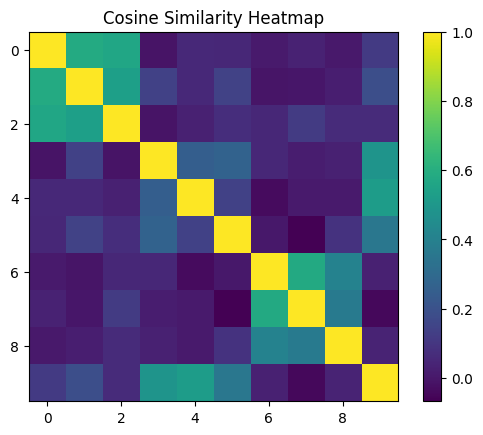

In [6]:
plt.imshow(similarity_matrix)
plt.colorbar()
plt.title("Cosine Similarity Heatmap")
plt.show()

In [7]:
query = "The bowler took three wickets in one over"

query_embedding = model.encode([query])

similarities = cosine_similarity(query_embedding, embeddings)[0]

# Get top 2 matches
top_indices = similarities.argsort()[-2:][::-1]

for i in top_indices:
    print("Sentence:", sentences[i])
    print("Similarity:", similarities[i])
    print()

Sentence: The bowler took a wicket in the final over
Similarity: 0.83883524

Sentence: The batsman scored a century in the match
Similarity: 0.56821966

